In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
plt.rc('font', size=20)
plt.rc('figure', figsize=(15,8))
import plotly.express as px
from plotly.offline import download_plotlyjs, init_notebook_mode
init_notebook_mode(connected=True)
from BopFoxFeaturizer.HelperFunctions import cleanfeaturenames
from Tools import Plotting, CaseNamer

In [2]:
from importlib.machinery import SourceFileLoader

In [3]:
CASE = 'INITIAL'  #, 'INITIAL', RELAXED
#MODEL = 'CANONICAL' #, 'ORTHOGONAL', 'CANONICAL'
CUT_OFF = 'TABLECUTOFF' # 'TABLECUTOFF', 'HISTCUTOFF'
E_MODE ='WUBIND'
C_RITERION = 'test_score'  # test_score, train_score, err
SEARCH_MODE = 'score_only' #score_only, index_too
TARGET = 'EF'

In [4]:
FileNamesCanonical = CaseNamer(
    CASE, 'CANONICAL',
    CUTOFF=CUT_OFF, EMODE=E_MODE, CRITERION=C_RITERION, SEARCHMODE=SEARCH_MODE, TARGET=TARGET
)

In [5]:
canonical_performance = pd.read_csv('tables/BopFeatures_Ubind_score_only_EF_test_score_score_only_CANONICAL_WUBIND_INITIAL_TABLECUTOFF.pdf.csv',header=None)

In [6]:
canonical_performance.columns=['Feature','Score']

In [7]:
orthogonal_performance = pd.read_csv('tables/BopFeatures_Ubind_score_only__test_score_score_only_ORTHOGONAL_WUBIND_INITIAL_TABLECUTOFF.pdf.csv',header=None)

In [8]:
orthogonal_performance.columns=['Feature','Score']

In [9]:
Atomic_performance = pd.read_csv('tables/AtomicFeatures___test_score__AtomicFeatures__initial_.pdf.csv',header=None)

In [10]:
Atomic_performance.columns=['Feature','Score']

In [11]:
feature_titles_canonical = pd.Series(cleanfeaturenames(canonical_performance['Feature'].str.replace('NSC_','').str.replace('bind_0','bind').str.replace('MagConfig_0','MagConfig')), index = canonical_performance['Feature'])

In [12]:
feature_titles_orthogonal = pd.Series(cleanfeaturenames(orthogonal_performance['Feature'].str.replace('NSC_','').str.replace('bind_0','bind').str.replace('MagConfig_0','MagConfig')), index = orthogonal_performance['Feature'])

In [13]:
orthogonalos_performance = pd.read_csv('tables/BopFeatures_Ubind_score_only_EF_test_score_score_only_ORTHOGONALOS_WUBIND_INITIAL_TABLECUTOFF.pdf.csv', header=None)

In [14]:
orthogonalos_performance.columns=['Feature','Score']

In [15]:
feature_titles_orthogonalos = pd.Series(cleanfeaturenames(orthogonalos_performance['Feature'].str.replace('NSC_','').str.replace('MagConfig_0','MagConfig')), index = orthogonalos_performance['Feature'])

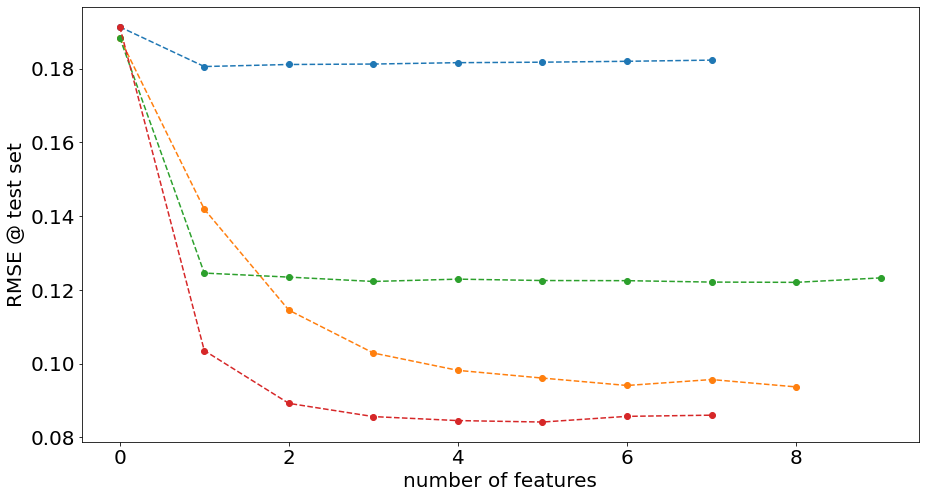

In [27]:
fig, ax = plt.subplots()
ax.plot(canonical_performance.index, canonical_performance['Score'],'o--', label='canonical model')
ax.plot(orthogonal_performance.index, orthogonal_performance['Score'],'o--', label='orthogonal sd')
ax.plot(Atomic_performance.index, Atomic_performance['Score'],'o--', label='atomic matminer features')
ax.plot(orthogonalos_performance.index, orthogonalos_performance['Score'],'o--', label='os + orthogonal sd')
ax.set_ylabel ('RMSE @ test set')
ax.set_xlabel ('number of features')
fig.savefig('graphs/incremental_domain_knowledge.pdf')

In [23]:
    Atomic_performance['Feature']=Atomic_performance['Feature'].str.replace('MagpieData','')

In [24]:
from importlib.machinery import SourceFileLoader

In [25]:
Atomic_performance['Feature'].drop(0)

1       mean AtomicWeight
2     avg_dev GSvolume_pa
3          mode NdValence
4         mode NpUnfilled
5         mode NfUnfilled
6          mode NsValence
7         mean NfUnfilled
8          mean NpValence
9       avg_dev NpValence
Name: Feature, dtype: object

In [26]:
Plotting = SourceFileLoader('Plotting','Tools.py').load_module().Plotting
ax1 = Plotting.plot_learning_curve( canonical_performance['Score'][1:].values,  feature_titles_canonical.drop('MagConfig_0'))
ax2 = Plotting.plot_learning_curve(orthogonal_performance['Score'][1:].values, feature_titles_orthogonal.drop('MagConfig_0'), ax = ax1)
ax3 = Plotting.plot_learning_curve(Atomic_performance['Score'][1:].values, Atomic_performance['Feature'].drop(0), ax = ax2)
ax3 = Plotting.plot_learning_curve(orthogonalos_performance['Score'][1:].values, feature_titles_orthogonalos.drop('MagConfig_0'), ax = ax2)

ValueError: 

^
Double subscript  (at char 0), (line:1, col:1)

<Figure size 1080x576 with 1 Axes>